# Name Classifier

In [192]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats

### Preprocessing
Names have already been sorted into those only appearing in the feminine names, those only appearing as masculine, and those appearing in both. For both masculine and feminine names, only those with the highest counts in their respective sets and those with the highest percent difference in the unisex set will be used.

In [159]:
fem = pd.read_csv("names/sortedFemale.txt")
masc = pd.read_csv("names/sortedMale.txt")
uni = pd.read_csv("names/unsortedUnisex.txt")
uni['majority_sex'] = uni.apply(lambda x : 'f' if x['female_sum'] > x['male_sum'] else 'm', axis = 1)

In [160]:
# looking at names, above 10000 seems to be a good sample
fem = fem[fem['count'] > 10000]
fem['sex'] = 'f'
masc = masc[masc['count'] > 10000]
masc['sex'] = 'm'

In [162]:
uni_fem = uni.copy()
uni_fem = uni_fem[uni_fem['majority_sex'] == 'f']
uni_fem['sex'] = uni_fem['majority_sex']
uni_fem = uni_fem[uni_fem['per_diff'] > 190]
uni_fem = uni_fem[uni_fem['female_sum'] > 50000] # this seems like a good number, totals are higher
uni_fem = uni_fem.sort_values(by = 'female_sum', ascending = False)
uni_fem['count'] = uni_fem['female_sum']
fem = pd.concat([fem, uni_fem[['name', 'count', 'sex']]], axis = 0)
fem = fem.sort_values(by = 'count', ascending = False).reset_index(drop = True)

In [163]:
uni_masc = uni.copy()
uni_masc = uni_masc[uni_masc['majority_sex'] == 'm']
uni_masc['sex'] = uni_masc['majority_sex']
uni_masc = uni_masc[uni_masc['per_diff'] > 190]
uni_masc = uni_masc[uni_masc['male_sum'] > 40000] # lowering because there are like 400 names
uni_masc = uni_masc.sort_values(by = 'male_sum', ascending = False)
uni_masc['count'] = uni_masc['male_sum']
masc = pd.concat([masc, uni_masc[['name', 'count', 'sex']]], axis = 0)
masc = masc.sort_values(by = 'count', ascending = False).reset_index(drop = True)

In [164]:
fem = fem.iloc[0:len(masc)] # ensuring 50/50 class split

In [120]:
# soundex generator function from GeeksForGeeks
def soundex_generator(token):
    token = token.upper()
    soundex = ""
    soundex += token[0]
    dictionary = {"BFPV": "1", "CGJKQSXZ": "2",
                  "DT": "3",
                  "L": "4", "MN": "5", "R": "6",
                  "AEIOUHWY": "0"} # I changed this to 0 from .
    for char in token[1:]:
        for key in dictionary.keys():
            if char in key:
                code = dictionary[key]
                if code != '.':
                    if code != soundex[-1]:
                        soundex += code
    soundex = soundex[:7].ljust(7, "0")
    return soundex[1:]

In [180]:
names = pd.concat([fem, masc], axis = 0)
names['length'] = names['name'].apply(lambda x :len(x))
vowels = 'aeiouy'
for v in vowels:
    names['end_' + v] = names['name'].apply(lambda x : 1 if x.endswith(v) else 0)
# metaphone does not produce numbers so I had to make it into numbers using soundex
names['soundex'] = names['name'].apply(lambda x : soundex_generator(x)).astype('int')
names['initial'] = names['name'].apply(lambda x : x[0])
names['is_male'] = names['sex'].apply(lambda x : 1 if x == 'm' else 0)
num_names = len(names)
names.head()

,name,count,sex,length,end_a,end_e,end_i,end_o,end_u,end_y,soundex,initial,is_male
0,mary,4139160,f,4,0,0,0,0,0,1,60000,m,0
1,elizabeth,1681878,f,9,0,0,0,0,0,0,402010,e,0
2,patricia,1573445,f,8,1,0,0,0,0,0,36020,p,0
3,jennifer,1471191,f,8,0,0,0,0,0,0,50106,j,0
4,linda,1454832,f,5,1,0,0,0,0,0,53000,l,0


### Graphs

Text(0, 0.5, 'count')

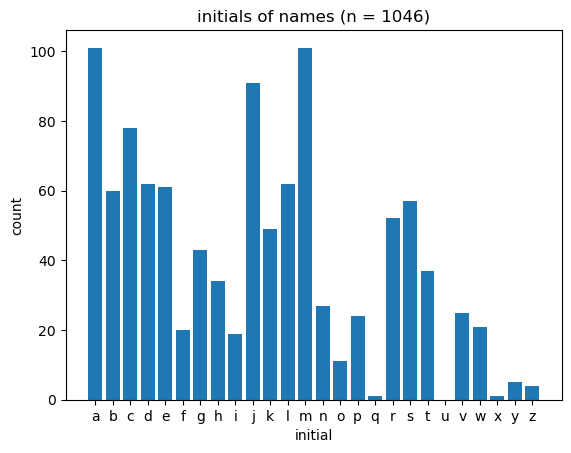

In [140]:
alphabet = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm',
            'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
initial_counts = {key : 0 for key in alphabet}
for n in range(len(names)):
    initial_counts[names['initial'].iloc[n]] += 1
plt.bar(range(len(initial_counts)), list(initial_counts.values()), align='center')
_ = plt.xticks(range(len(initial_counts)), list(initial_counts.keys()))
plt.title(f'initials of names (n = {num_names})')
plt.xlabel('initial')
plt.ylabel('count')

Text(0, 0.5, 'count')

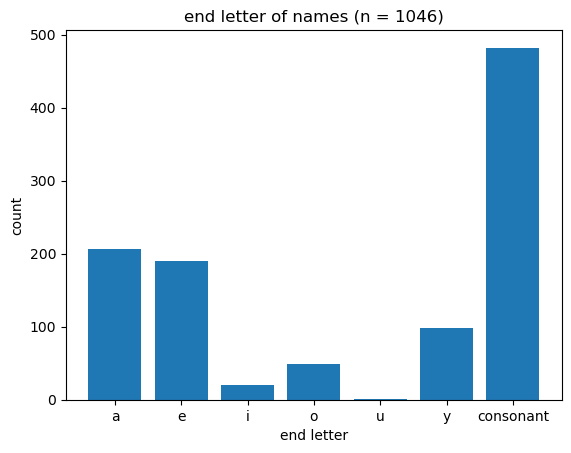

In [145]:
ends = {key : 0 for key in vowels}
for v in vowels:
    ends[v] = names['end_' + v].sum()
ends['consonant'] = num_names - sum(ends.values())
plt.bar(range(len(ends)), list(ends.values()), align='center')
_ = plt.xticks(range(len(ends)), list(ends.keys()))
plt.title(f'end letter of names (n = {num_names})')
plt.xlabel('end letter')
plt.ylabel('count')

Text(0, 0.5, 'count')

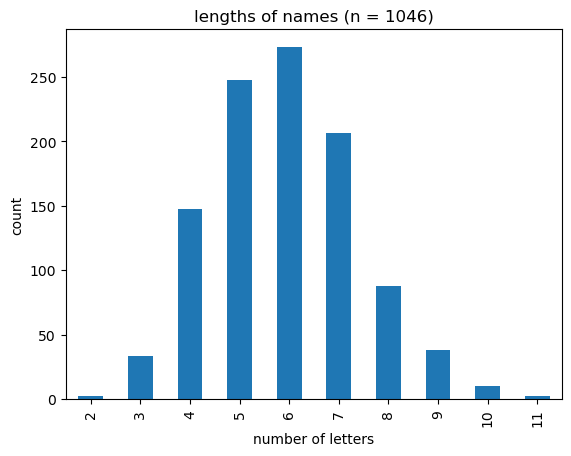

In [158]:
names['length'].value_counts().sort_index().plot(kind = 'bar')
plt.title(f'lengths of names (n = {num_names})')
plt.xlabel('number of letters')
plt.ylabel('count')

Text(0, 0.5, 'count')

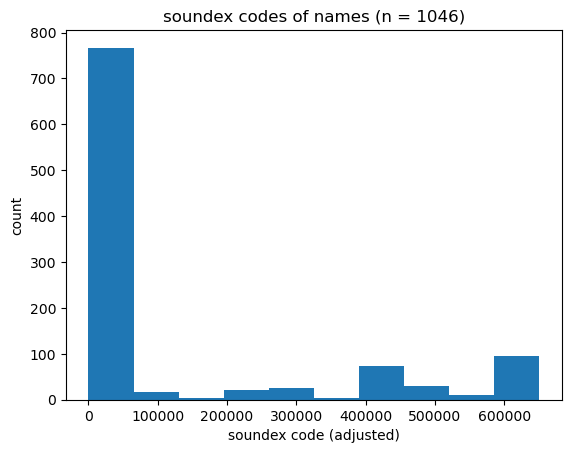

In [183]:
names['soundex'].plot.hist()
plt.title(f'soundex codes of names (n = {num_names})')
plt.xlabel('soundex code (adjusted)')
plt.ylabel('count')

Text(0, 0.5, 'count')

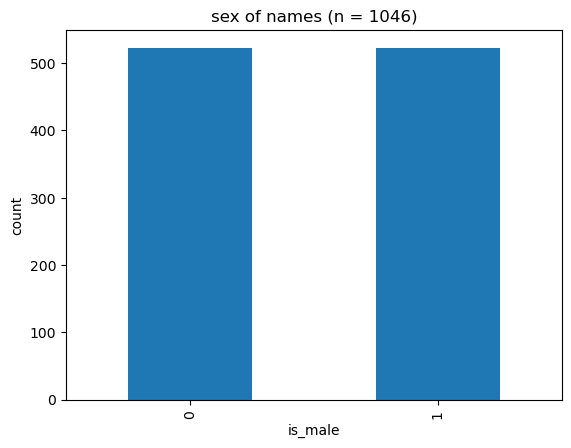

In [189]:
names['is_male'].value_counts().sort_index().plot(kind = 'bar')
plt.title(f'sex of names (n = {num_names})')
plt.xlabel('is_male')
plt.ylabel('count')

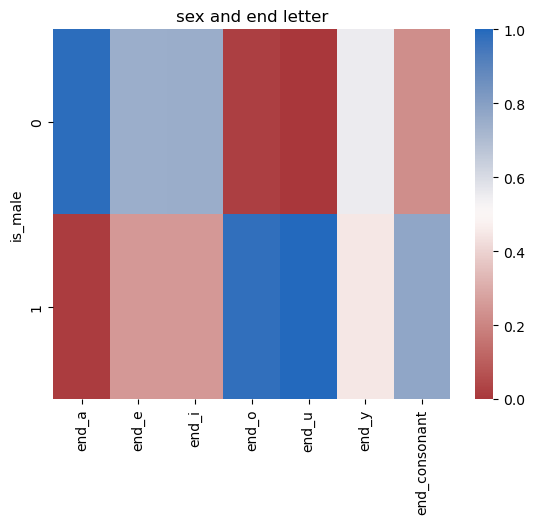

In [191]:
names['end_consonant'] = names['name'].apply(lambda x : 1 if x[-1] not in vowels else 0)
end_cols = ['end_a', 'end_e', 'end_i', 'end_o', 'end_u', 'end_y', 'end_consonant']
table = names.groupby('is_male')[end_cols].mean()
table = table.apply(lambda x : x / x.sum())
sns.heatmap(table, cmap = 'vlag_r').set_title('sex and end letter')
names = names.drop('end_consonant', axis = 1)

Text(0.5, 1.0, 'sex and initial letter')

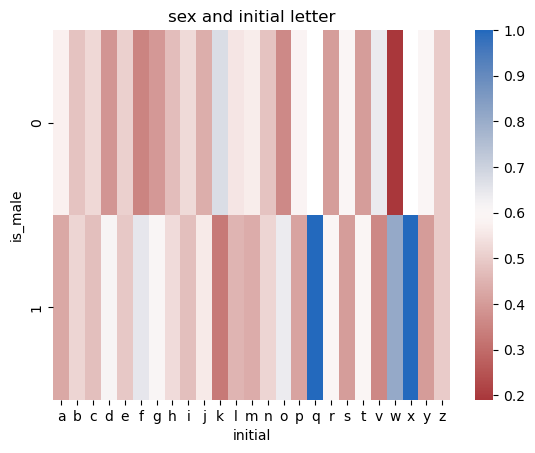

In [174]:
table = pd.pivot_table(names[['is_male', 'initial']], index = ['is_male'], columns = ['initial'], 
			         values = ['is_male'], aggfunc = np.size)
table = table.apply(lambda x : x / x.sum())
sns.heatmap(table, cmap = 'vlag_r').set_title('sex and initial letter')

Text(0.5, 1.0, 'length of name by sex')

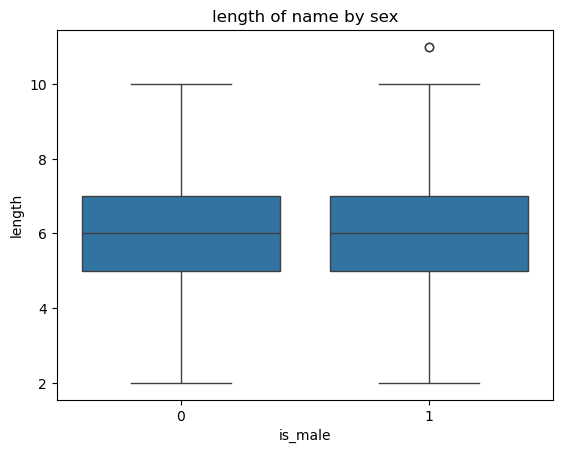

In [177]:
sns.boxplot(x = names['is_male'], y = names['length'])
plt.title('length of name by sex')

Text(0.5, 1.0, 'soundex code (adjusted) of name by sex')

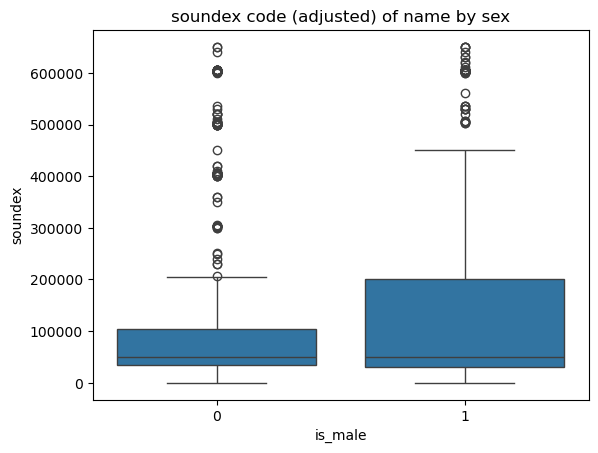

In [186]:
sns.boxplot(x = names['is_male'], y = names['soundex'])
plt.title('soundex code (adjusted) of name by sex')

### Statistical Testing

In [199]:
num_tests = 53
y = names['is_male']
X = names.drop(['name', 'count', 'sex', 'initial', 'is_male', 'soundex'], axis = 1)
cat = ['end_a', 'end_e', 'end_i', 'end_o', 'end_u', 'end_y']
num = ['length', 'soundex']
for c in cat:
    combination = pd.crosstab(names['is_male'], names[c])
    chi, p, x, x = stats.chi2_contingency(combination)
    print(f"{c:<10}\t p-value: {p:<30}\t chi: {chi:<20}\t significant: {p<=(0.05/num_tests)}")
t, p = stats.ttest_ind(names[names['is_male'] == 0]['length'], names[names['is_male'] == 1]['length'])
print(f"Length\t\t p-value: {p:<30}\t t-stat: {t:<20}\t significant: {p<=(0.05/num_tests)}")
# t, p = stats.ttest_ind(names[names['is_male'] == 0]['soundex'], names[names['is_male'] == 1]['soundex'])
# print(f"Soundex\t\t p-value: {p:<30}\t t-stat: {t:<20}\t significant: {p<=(0.05/num_tests)}")

end_a     	 p-value: 5.363855535724084e-54         	 chi: 239.3819116967175   	 significant: True
end_e     	 p-value: 8.770008690885449e-14         	 chi: 55.625024594195764  	 significant: True
end_i     	 p-value: 0.042155564913105105          	 chi: 4.128947368421052   	 significant: False
end_o     	 p-value: 1.6852853746273474e-11        	 chi: 45.306040570691664  	 significant: True
end_u     	 p-value: 1.0                           	 chi: 0.0                 	 significant: False
end_y     	 p-value: 0.3395912930265326            	 chi: 0.9119736502195815  	 significant: False
Length		 p-value: 0.013115659616163117          	 t-stat: 2.4848694056340563  	 significant: False


### Classifier

In [200]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [201]:
from sklearn.linear_model import LogisticRegression
logit = LogisticRegression(random_state=0).fit(X_train, y_train)

In [202]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
pred = logit.predict(X_test)
print(f"Logit accuracy: {accuracy_score(y_test, pred)}")
print(f"Logit f1 score: {f1_score(y_test, pred)}\n")

Logit accuracy: 0.8047619047619048
Logit f1 score: 0.8056872037914692

